Zero Initialization Problem in Weight Initialization

https://cs230.stanford.edu/section/4/

https://www.deeplearning.ai/ai-notes/initialization/index.html

In [1]:
import numpy as np
import pandas as pd

# Number of rows
n = 100

# Generate random floats for X and Y
X = np.round(np.random.uniform(-2.0, 3.0, n), 4)   # values between -2 and 3
Y = np.round(np.random.uniform(-1.0, 1.0, n), 4)   # values between -1 and 1

# Generate binary class labels (0.0 or 1.0)
classes = np.random.choice([0.0, 1.0], size=n)

# Create DataFrame
df = pd.DataFrame({
    "X": X,
    "Y": Y,
    "class": classes
})

# Add index column
df.reset_index(inplace=True)

# Show first 10 rows
print(df.head(10))

# Save to CSV if needed
df.to_csv("synthetic_dataset.csv", index=False)


   index       X       Y  class
0      0  1.4609 -0.6585    0.0
1      1 -1.4656  0.0195    1.0
2      2  2.7821  0.1959    1.0
3      3 -1.6451 -0.1581    1.0
4      4  1.8088 -0.4874    0.0
5      5 -0.3256 -0.0696    0.0
6      6  1.1581  0.7412    0.0
7      7  1.6721 -0.9226    1.0
8      8  0.4646 -0.7777    0.0
9      9 -1.8470  0.7125    1.0


In [2]:
df.head()

,index,X,Y,class
0,0,1.4609,-0.6585,0.0
1,1,-1.4656,0.0195,1.0
2,2,2.7821,0.1959,1.0
3,3,-1.6451,-0.1581,1.0
4,4,1.8088,-0.4874,0.0


<IPython.core.display.Javascript object>

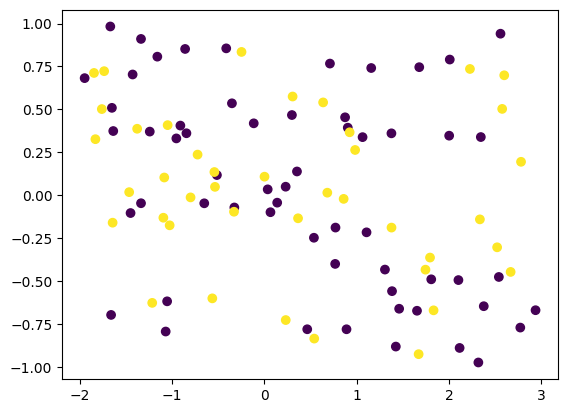

In [3]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [4]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [5]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [6]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\Meghali\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Set parameters to 0
model.get_weights()

[array([[-0.2324284 ,  0.66180867,  0.50125855, -0.18989736, -0.54468125,
          0.45587784,  0.00857335, -0.12910354,  0.05815673,  0.21204722],
        [ 0.1695984 ,  0.36025375, -0.5537148 , -0.16454351, -0.26341307,
          0.47684354,  0.08595359,  0.0255233 , -0.5317145 , -0.45576116]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.36616796],
        [ 0.19986671],
        [ 0.25739592],
        [ 0.13704532],
        [-0.5932795 ],
        [-0.06183708],
        [ 0.09058297],
        [ 0.41287404],
        [-0.14029968],
        [ 0.21728545]], dtype=float32),
 array([0.], dtype=float32)]

In [8]:
initial_weights = model.get_weights()

In [9]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [10]:
model.set_weights(initial_weights)

In [11]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [13]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.6000 - loss: 0.6933 - val_accuracy: 0.5500 - val_loss: 0.6925
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6000 - loss: 0.6917 - val_accuracy: 0.5500 - val_loss: 0.6921
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6000 - loss: 0.6907 - val_accuracy: 0.5500 - val_loss: 0.6915
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6000 - loss: 0.6894 - val_accuracy: 0.5500 - val_loss: 0.6908
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6000 - loss: 0.6880 - val_accuracy: 0.5500 - val_loss: 0.6901
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6000 - loss: 0.6865 - val_accuracy: 0.5500 - val_loss: 0.6895
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6000 - loss: 0.6856 - val_accuracy: 0.5500 - val_loss: 0.6889
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6000 - loss: 0.6843 - val_accuracy: 0.5500 - val_loss

In [14]:
model.get_weights()

[array([[0.05971941, 0.05971941, 0.05971941, 0.05971941, 0.05971941,
         0.05971941, 0.05971941, 0.05971941, 0.05971941, 0.05971941],
        [0.13198926, 0.13198926, 0.13198926, 0.13198926, 0.13198926,
         0.13198926, 0.13198926, 0.13198926, 0.13198926, 0.13198926]],
       dtype=float32),
 array([0.05009022, 0.05009022, 0.05009022, 0.05009022, 0.05009022,
        0.05009022, 0.05009022, 0.05009022, 0.05009022, 0.05009022],
       dtype=float32),
 array([[-0.04360278],
        [-0.04360278],
        [-0.04360278],
        [-0.04360278],
        [-0.04360278],
        [-0.04360278],
        [-0.04360278],
        [-0.04360278],
        [-0.04360278],
        [-0.04360278]], dtype=float32),
 array([-0.03826522], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 835us/step


<Axes: >

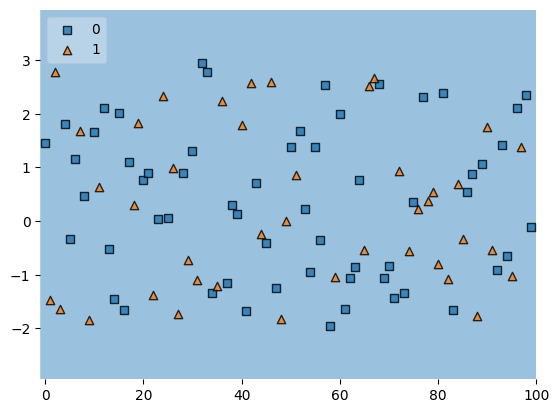

In [15]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 837us/step


<Axes: >

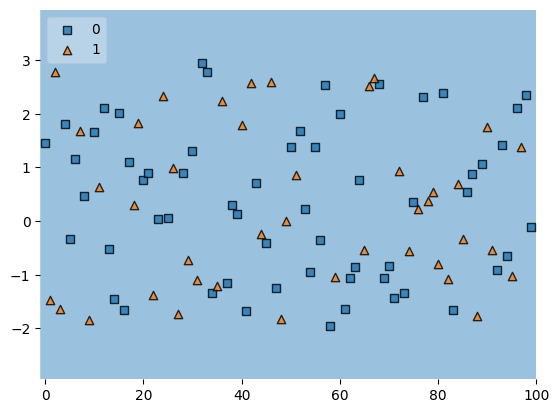

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)